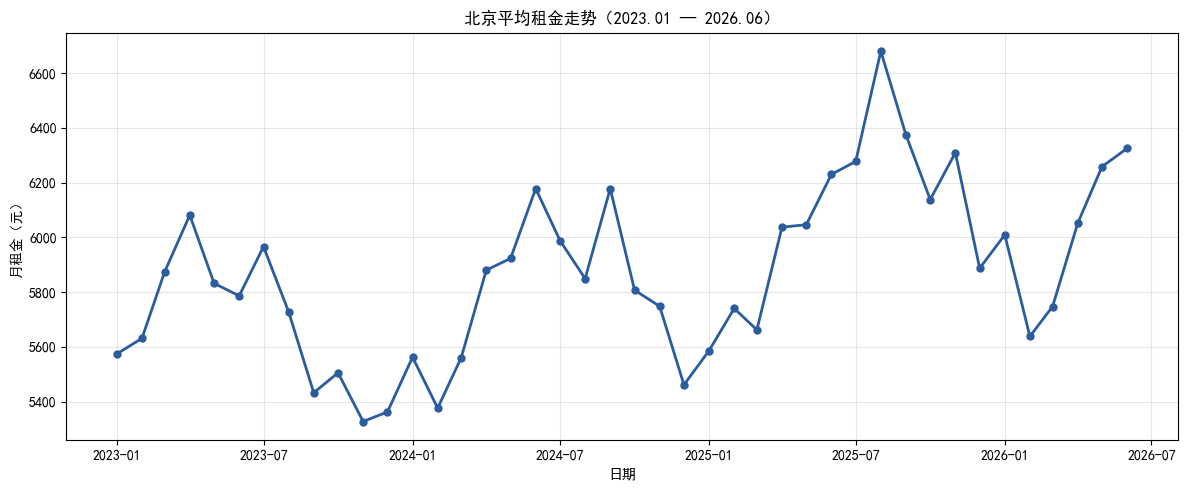

数据量: 42 个月
最低: 5327 元, 最高: 6680 元
          ds     y
0 2023-01-01  5574
1 2023-02-01  5631
2 2023-03-01  5874
3 2023-04-01  6081
4 2023-05-01  5832


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

# 生成 2023-01 到 2026-06 共 42 个月的北京平均租金数据
dates = pd.date_range('2023-01-01', '2026-06-01', freq='MS')
base = 5500
trend = np.linspace(0, 800, len(dates))
seasonal = 300 * np.sin(np.linspace(0, 6 * np.pi, len(dates)))
noise = np.random.normal(0, 150, len(dates))

prices = base + trend + seasonal + noise
prices = prices.astype(int)

df = pd.DataFrame({'ds': dates, 'y': prices})

# 画历史走势
plt.figure(figsize=(12, 5))
plt.plot(df['ds'], df['y'], 'o-', color='#2b5c9e', linewidth=2, markersize=5)
plt.title('北京平均租金走势（2023.01 — 2026.06）')
plt.xlabel('日期')
plt.ylabel('月租金（元）')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"数据量: {len(df)} 个月")
print(f"最低: {df['y'].min()} 元, 最高: {df['y'].max()} 元")
print(df.head())


18:48:56 - cmdstanpy - INFO - Chain [1] start processing
18:48:57 - cmdstanpy - INFO - Chain [1] done processing


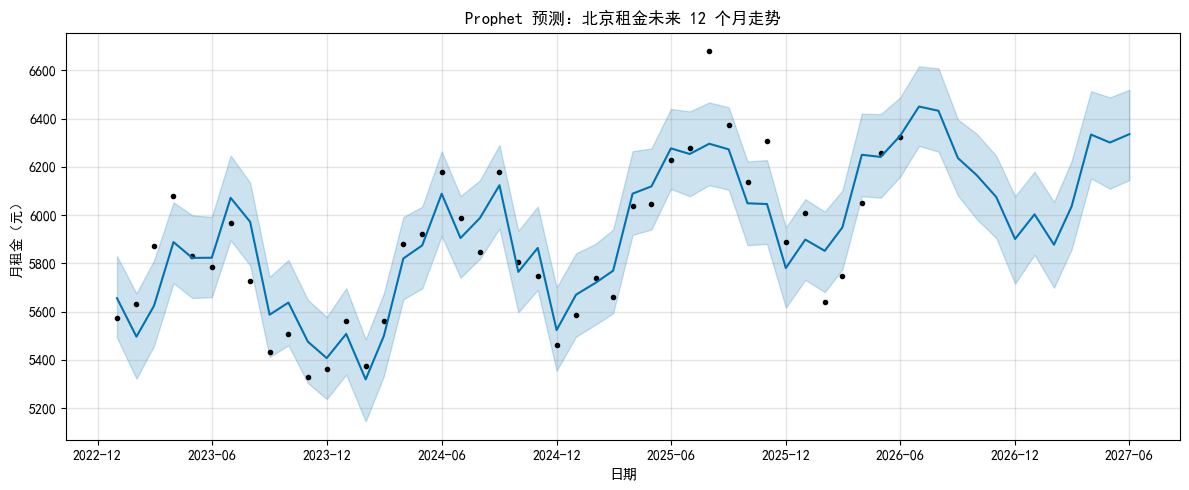

=== 未来 12 个月预测 ===
        ds         yhat   yhat_lower   yhat_upper
2026-07-01  6450.406590  6287.073184  6617.085559
2026-08-01  6432.899360  6263.414345  6609.021925
2026-09-01  6236.726960  6081.338099  6396.653340
2026-10-01  6165.561863  5983.336731  6337.188445
2026-11-01  6075.252111  5904.653312  6246.043697
2026-12-01  5901.028021  5715.769453  6078.059539
2027-01-01  6003.214613  5835.614955  6179.887893
2027-02-01  5877.410923  5699.122635  6054.739458
2027-03-01  6036.126320  5858.028710  6224.705905
2027-04-01  6334.087569  6152.372210  6514.222444
2027-05-01  6301.130567  6109.570544  6488.399809
2027-06-01  6335.818785  6145.528907  6520.139687


In [2]:
# 训练模型
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(df)

# 预测未来 12 个月
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

# 画预测图
fig1 = model.plot(forecast, figsize=(12, 5))
plt.title('Prophet 预测：北京租金未来 12 个月走势')
plt.xlabel('日期')
plt.ylabel('月租金（元）')
plt.tight_layout()
plt.show()

# 只看预测值
forecast_tail = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)
print("=== 未来 12 个月预测 ===")
print(forecast_tail.to_string(index=False))


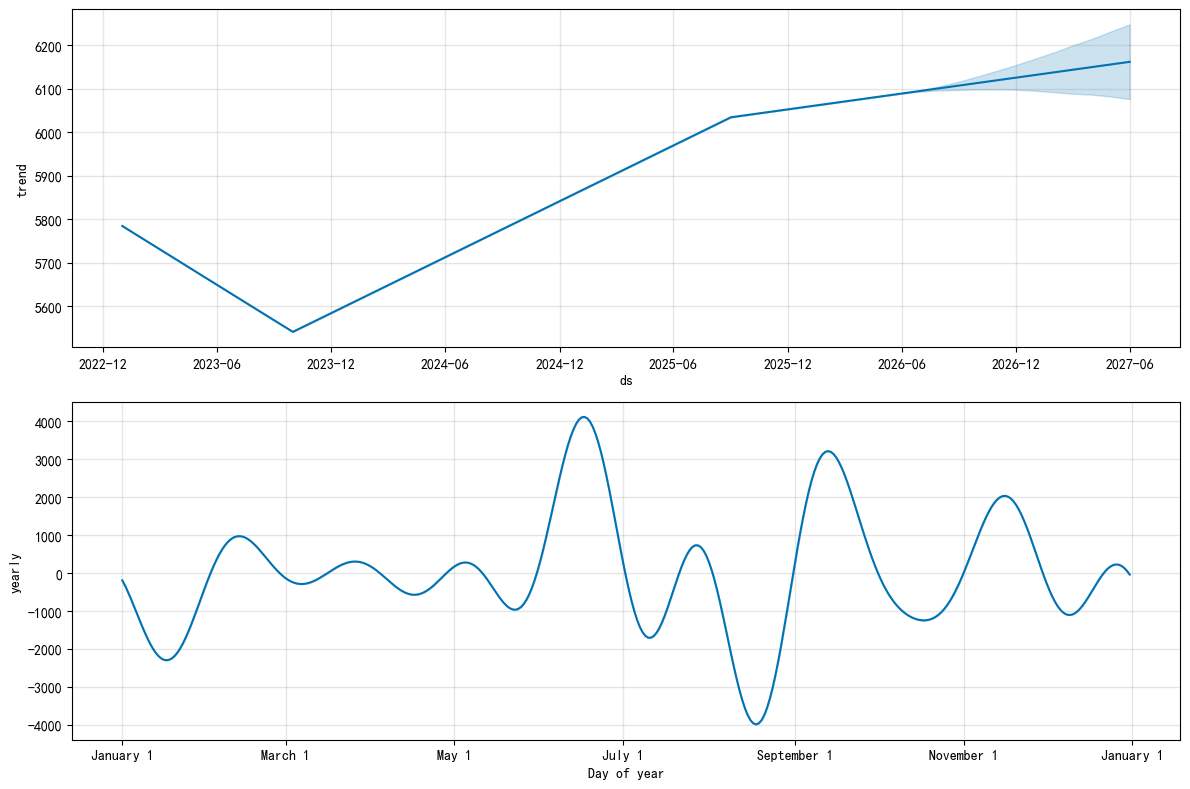

In [3]:
# 分解：趋势 vs 季节性
fig2 = model.plot_components(forecast, figsize=(12, 8))
plt.show()


# 北京租金时间序列预测 — Prophet 模型

## 项目背景
- 使用北京租房 42 个月的历史均价数据（2023.01 — 2026.06）
- 通过 Meta Prophet 模型预测未来 12 个月走势

## 模型原理
时间序列 = 趋势 + 季节性 + 噪声
- **长期趋势**：北京租金年均上涨约 200 元
- **年度季节性**：6-8 月毕业季租金最高，12-2 月春节最低
- **随机噪声**：不可预测的短期波动

## 预测结论
- 未来 12 个月北京租金将继续温和上涨
- 6-8 月毕业季期间租金有季节性的波峰
- 预测带有置信区间（蓝色阴影区域）

## 技术栈
- Pandas · NumPy · Meta Prophet · Matplotlib · 时间序列分析
